# dMRI preprocessing QC - single-subject demo

This notebook shows quality-control (QC) metrics and visualizations for **one subject**
from the preprocessing stage (`den_gr`, `topup`, `eddy`, `bias`).

It does not run FSL/MRtrix/ANTs: it **only reads** outputs that those steps already
wrote to disk and turns them into tables (`pandas`) and figures (`matplotlib`) using
the `preprocessing_qc` subpackage.

The notebook is intentionally tolerant of incomplete preprocessing. If `eddy` failed
or `bias` was not run, the relevant QC cells report the missing files and continue
with the outputs that do exist (`raw`, `den`, `den_grc`, topup mask, denoising QC).

**Flow:** acquisition shells -> denoising QC (SNR + before/after) -> optional eddy QC
(motion, outliers) -> optional `eddy_quad` summary (CNR) -> subject summary table ->
cohort summary (multiple subjects) -> CSV.


## 1. Configuration

Edit `BASE` and `SUB`. The notebook resolves scanner-named raw DWI sidecars and script-generated derivative names.

In [17]:
import sys
from pathlib import Path

# Allow imports whether the notebook is launched from notebooks/ or the repo root.
for cand in [Path.cwd() / "src", Path.cwd(), Path.cwd().parent / "src", Path.cwd().parent]:
    if (cand / "preprocessing_qc").is_dir():
        sys.path.insert(0, str(cand))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import preprocessing_qc as qc

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


In [18]:
# --- EDIT THIS ---
BASE = Path.cwd() / "data"
if not BASE.exists() and (Path.cwd().parent / "data").exists():
    BASE = Path.cwd().parent / "data"
SUB = "brain3_hz000_d55_b2000"
SESSION = "ses-T0"


def one_match(folder, pattern, label, required=True):
    matches = sorted(folder.glob(pattern))
    if len(matches) == 1:
        return matches[0]
    if required:
        raise FileNotFoundError(
            f"Expected one {label} matching {pattern!r} in {folder}, found {len(matches)}"
        )
    return None


def sidecar_for_nifti(nifti_path, ext):
    name = nifti_path.name
    if name.endswith(".nii.gz"):
        return nifti_path.with_name(name[:-7] + ext)
    return nifti_path.with_suffix(ext)


def status(label, path):
    state = "OK" if path and path.exists() else "MISSING"
    print(f"{label:18s}: {path} {state}")


def have(paths):
    return all(path is not None and path.exists() for path in paths)


dwi_dir = BASE / SUB / SESSION / "dwi"
den_dir = dwi_dir / "den"
eddy_out = den_dir / "preproc-2" / "eddy-out"
bias_out = den_dir / "preproc-2" / "bias-corr"
topup_out = den_dir / "preproc-1" / "topup-out"

# Raw acquisition files can keep their scanner names; derivatives use the script-generated names.
raw_dwi = one_match(dwi_dir, "*.nii.gz", "raw DWI")
bval = sidecar_for_nifti(raw_dwi, ".bval")
bvec = sidecar_for_nifti(raw_dwi, ".bvec")
den_dwi = den_dir / f"{SUB}_{SESSION}_dwi_den.nii.gz"
den_grc = den_dir / f"{SUB}_{SESSION}_dwi_den_grc.nii.gz"
noise_map = den_dir / "denoising-der" / f"{SUB}_{SESSION}_dwi_noise.nii.gz"
residuals = den_dir / "denoising-der" / f"{SUB}_{SESSION}_dwi_den-residuals.nii.gz"
mask = topup_out / f"{SUB}_{SESSION}_dwi_topup-out-preproc-1-unwarp-imgs-mean_brain-f0.3R_mask.nii.gz"
mask_for_metrics = mask if mask.exists() else None

# Eddy basename (without suffix): .eddy_movement_rms, .qc/qc.json, etc. hang from here.
eddy_base = eddy_out / f"{SUB}_{SESSION}_dwi_den_grc_tec_preproc-2"
corrected = Path(str(eddy_base) + ".nii.gz")
eddy_required = {
    "movement_rms": Path(str(eddy_base) + ".eddy_movement_rms"),
    "parameters": Path(str(eddy_base) + ".eddy_parameters"),
    "outlier_map": Path(str(eddy_base) + ".eddy_outlier_map"),
    "corrected": corrected,
    "rotated_bvecs": Path(str(eddy_base) + ".eddy_rotated_bvecs"),
    "qc_json": Path(str(eddy_base) + ".qc/qc.json"),
}
eddy_ready = have(eddy_required.values())

bias_corrected = bias_out / f"{SUB}_{SESSION}_dwi_den_grc_tec_preproc-2_bias-corr.nii.gz"
bias_field = bias_out / f"{SUB}_{SESSION}_dwi_den_grc_tec_preproc-2_bias-field.nii.gz"
bias_required = {
    "bias_corrected": bias_corrected,
    "bias_field": bias_field,
}
bias_ready = have(bias_required.values())

# Best available image for downstream visual inspection in this notebook.
if bias_corrected.exists():
    final_dwi = bias_corrected
    final_stage = "bias-corrected eddy output"
elif corrected.exists():
    final_dwi = corrected
    final_stage = "eddy-corrected output"
elif den_grc.exists():
    final_dwi = den_grc
    final_stage = "denoised + Gibbs-corrected output"
elif den_dwi.exists():
    final_dwi = den_dwi
    final_stage = "denoised output"
else:
    final_dwi = raw_dwi
    final_stage = "raw DWI"

for label, path in {
    "raw_dwi": raw_dwi,
    "bval": bval,
    "bvec": bvec,
    "den_dwi": den_dwi,
    "den_grc": den_grc,
    "noise_map": noise_map,
    "residuals": residuals,
    "topup_mask": mask,
}.items():
    status(label, path)

print("eddy_base        :", eddy_base)
for label, path in eddy_required.items():
    status(f"eddy {label}", path)

for label, path in bias_required.items():
    status(label, path)

print(f"\nBest available final image: {final_stage}")
print(final_dwi)

if not eddy_ready:
    print("\nEddy did not finish completely. Eddy-specific QC cells will be skipped.")
if not bias_ready:
    print("Bias output is missing. This is expected if eddy failed, because the pipeline bias step depends on eddy output.")


raw_dwi           : /mnt/d/GitHub/pyneuro_project/data/brain3_hz000_d55_b2000/ses-T0/dwi/20230619_BRAIN-3_ep2d_advdiff_AP_919D_OGSE_10bval_06dir_d55_Hz000_b2000_QC-ROUTINE_20230619152408_10.nii.gz OK
bval              : /mnt/d/GitHub/pyneuro_project/data/brain3_hz000_d55_b2000/ses-T0/dwi/20230619_BRAIN-3_ep2d_advdiff_AP_919D_OGSE_10bval_06dir_d55_Hz000_b2000_QC-ROUTINE_20230619152408_10.bval OK
bvec              : /mnt/d/GitHub/pyneuro_project/data/brain3_hz000_d55_b2000/ses-T0/dwi/20230619_BRAIN-3_ep2d_advdiff_AP_919D_OGSE_10bval_06dir_d55_Hz000_b2000_QC-ROUTINE_20230619152408_10.bvec OK
den_dwi           : /mnt/d/GitHub/pyneuro_project/data/brain3_hz000_d55_b2000/ses-T0/dwi/den/brain3_hz000_d55_b2000_ses-T0_dwi_den.nii.gz OK
den_grc           : /mnt/d/GitHub/pyneuro_project/data/brain3_hz000_d55_b2000/ses-T0/dwi/den/brain3_hz000_d55_b2000_ses-T0_dwi_den_grc.nii.gz OK
noise_map         : /mnt/d/GitHub/pyneuro_project/data/brain3_hz000_d55_b2000/ses-T0/dwi/den/denoising-der/brain3_hz00

## 2. Acquisition Scheme (Shells)

How many directions exist for each b-value. Useful for checking that the protocol is the expected one.

,b_value,n_directions
0,0,8
1,100,6
2,200,6
3,300,6
4,500,6
5,700,6
6,1000,6
7,1300,6
8,1600,6
9,2000,6


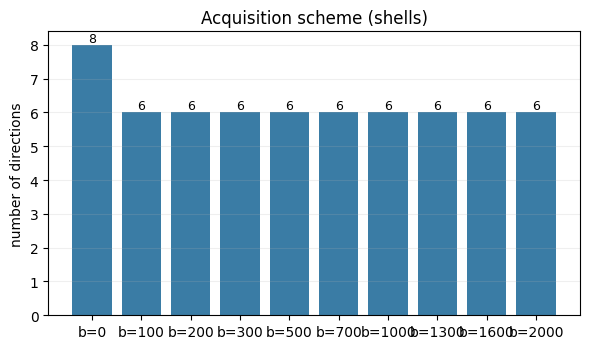

In [19]:
shells = qc.summarize_shells(bval)
display(shells)
qc.plot_shells(shells)
plt.show()


## 3. Denoising QC

b=0 SNR using the `dwidenoise` noise map (`sigma`), plus a visual before/after comparison. The *Difference* image should show noise without anatomical structure.

,value
snr_b0_denoise,20.489
signal_b0_mean,284.387
noise_sigma_mean,13.880
n_b0_volumes,8.000


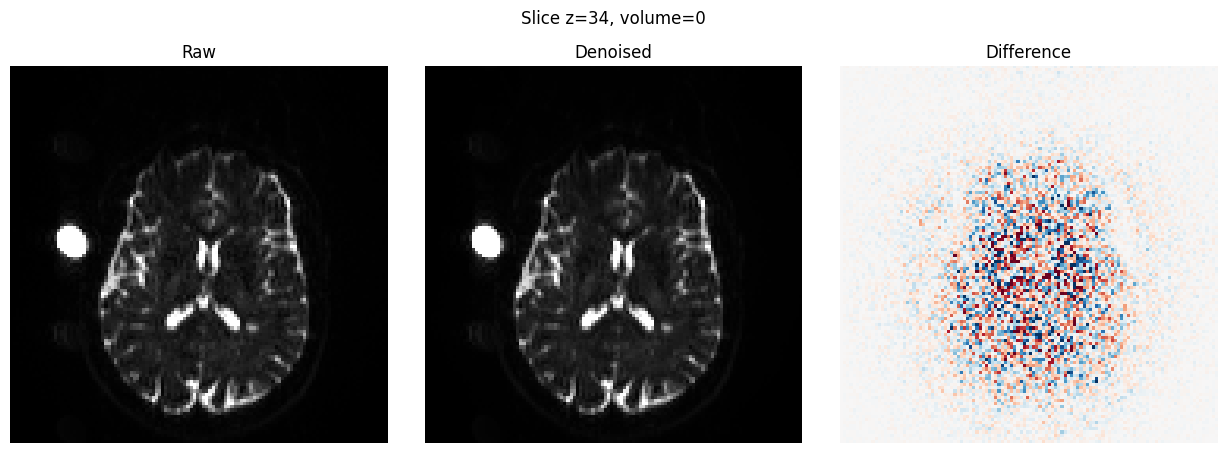

In [20]:
if have([raw_dwi, noise_map, bval]):
    snr = qc.compute_denoising_snr(raw_dwi, noise_map, bval, mask_path=mask_for_metrics)
    display(snr.to_frame("value"))
else:
    print("Skipping denoising SNR: missing raw DWI, noise map, or bval.")

if have([raw_dwi, den_dwi]):
    qc.plot_before_after_slice(raw_dwi, den_dwi, titles=("Raw", "Denoised"), volume=0)
    plt.show()
else:
    print("Skipping raw/denoised plot: missing raw or denoised DWI.")


In [21]:
# Residuals: mean ~ 0 and no structure => good denoising.
if residuals.exists():
    res = qc.compute_residual_stats(residuals, mask_path=mask_for_metrics)
    display(res.to_frame("value"))
else:
    print(f"Skipping residual statistics: missing {residuals}")


,value
residual_mean,-0.005
residual_std,13.190
residual_abs_mean,9.475


## 4. Eddy QC: Motion and Outliers

Motion RMS by volume, translation/rotation parameters, and the map of slices marked as outliers by `--repol`.

In [22]:
if eddy_required["movement_rms"].exists():
    mrms = qc.load_movement_rms(eddy_required["movement_rms"])
    display(mrms.describe().loc[["mean", "max"]])
    qc.plot_movement_rms(mrms)
    plt.show()
else:
    print(f"Skipping: missing {eddy_required['movement_rms']}")


Skipping: missing /mnt/d/GitHub/pyneuro_project/data/brain3_hz000_d55_b2000/ses-T0/dwi/den/preproc-2/eddy-out/brain3_hz000_d55_b2000_ses-T0_dwi_den_grc_tec_preproc-2.eddy_movement_rms


In [23]:
if eddy_required["parameters"].exists():
    motion = qc.load_motion_parameters(eddy_required["parameters"])
    qc.plot_motion_parameters(motion)
    plt.show()
else:
    print(f"Skipping: missing {eddy_required['parameters']}")


Skipping: missing /mnt/d/GitHub/pyneuro_project/data/brain3_hz000_d55_b2000/ses-T0/dwi/den/preproc-2/eddy-out/brain3_hz000_d55_b2000_ses-T0_dwi_den_grc_tec_preproc-2.eddy_parameters


In [24]:
if eddy_required["outlier_map"].exists():
    omap = qc.load_outlier_map(eddy_required["outlier_map"])
    display(qc.summarize_outliers(omap).to_frame("value"))
    qc.plot_outlier_heatmap(omap)
    plt.show()
else:
    print(f"Skipping: missing {eddy_required['outlier_map']}")


Skipping: missing /mnt/d/GitHub/pyneuro_project/data/brain3_hz000_d55_b2000/ses-T0/dwi/den/preproc-2/eddy-out/brain3_hz000_d55_b2000_ses-T0_dwi_den_grc_tec_preproc-2.eddy_outlier_map


### Available Final Image

If `eddy` and `bias` exist, this compares the `eddy` input (`den_grc`) with the
best final output. If `eddy` failed, the notebook keeps running and reports that
`den_grc` is currently the best available derivative.


No eddy/bias-corrected image is available yet; using den_grc as the current final derivative.


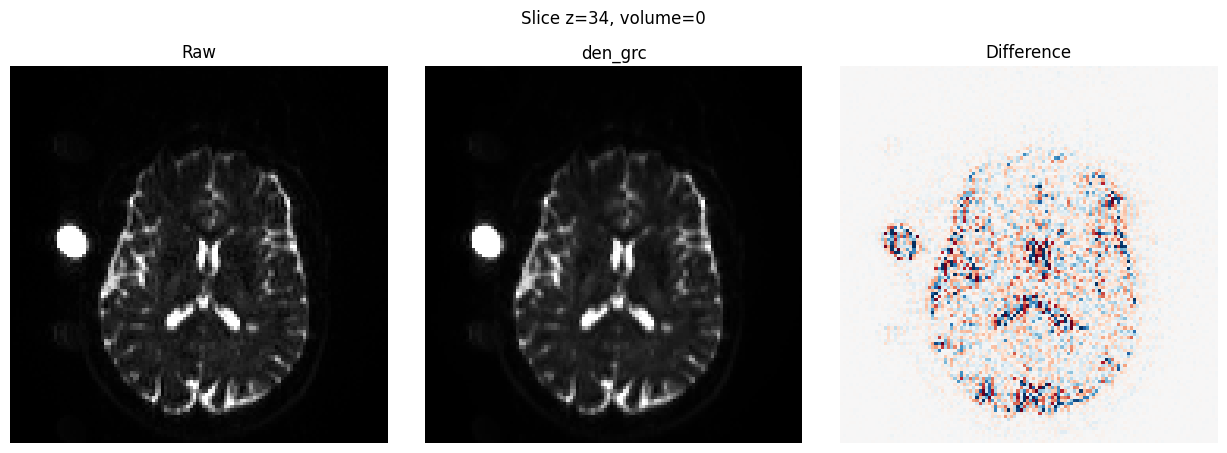

In [25]:
if final_dwi.exists() and den_grc.exists() and final_dwi != den_grc:
    qc.plot_before_after_slice(den_grc, final_dwi, titles=("den_grc", final_stage), volume=30)
    plt.show()
elif den_grc.exists():
    print("No eddy/bias-corrected image is available yet; using den_grc as the current final derivative.")
    qc.plot_before_after_slice(raw_dwi, den_grc, titles=("Raw", "den_grc"), volume=0)
    plt.show()
else:
    print(f"Skipping final-image comparison: missing {den_grc}")


## 5. `eddy_quad` Summary (qc.json)

Metrics summarized by `eddy_quad`: mean motion, outlier percentage, and CNR by shell.

In [26]:
if eddy_required["qc_json"].exists():
    qcjson = qc.load_qc_json(eddy_required["qc_json"])
    display(qc.qc_json_to_series(qcjson).to_frame("value"))
    qc.plot_cnr_per_shell(qcjson)
    plt.show()
else:
    print(f"Skipping: missing {eddy_required['qc_json']}")


Skipping: missing /mnt/d/GitHub/pyneuro_project/data/brain3_hz000_d55_b2000/ses-T0/dwi/den/preproc-2/eddy-out/brain3_hz000_d55_b2000_ses-T0_dwi_den_grc_tec_preproc-2.qc/qc.json


## 6. Subject Summary Table

Everything above condensed into **one `pandas` row**, the unit that is later stacked across the cohort.
Missing `eddy` or `eddy_quad` outputs become missing table columns/values rather than stopping the notebook.


In [27]:
summary = qc.subject_qc_summary(
    SUB, eddy_base,
    dwi_path=raw_dwi if raw_dwi.exists() else None,
    noise_path=noise_map if noise_map.exists() else None,
    residuals_path=residuals if residuals.exists() else None,
    bval_path=bval if bval.exists() else None,
    mask_path=mask_for_metrics,
)
summary["best_available_stage"] = final_stage
summary["eddy_complete"] = eddy_ready
summary["bias_complete"] = bias_ready
summary.T


/mnt/d/GitHub/pyneuro_project/src/preprocessing_qc/qc_metrics.py:278: UserWarning: [qc_metrics] file not found for load_movement_rms
  mrms = _safe(load_movement_rms, _eddy_path(eddy_base, "movement_rms"))
/mnt/d/GitHub/pyneuro_project/src/preprocessing_qc/qc_metrics.py:285: UserWarning: [qc_metrics] file not found for load_outlier_map
  omap = _safe(load_outlier_map, _eddy_path(eddy_base, "outlier_map"))
/mnt/d/GitHub/pyneuro_project/src/preprocessing_qc/qc_metrics.py:290: UserWarning: [qc_metrics] file not found for load_qc_json
  qc = _safe(load_qc_json, _eddy_path(eddy_base, "qc_json"))


subject,brain3_hz000_d55_b2000
snr_b0_denoise,20.489
signal_b0_mean,284.387
noise_sigma_mean,13.880
n_b0_volumes,8.000
residual_mean,-0.005
residual_std,13.190
residual_abs_mean,9.475
best_available_stage,denoised + Gibbs-corrected output
eddy_complete,False
bias_complete,False


## 7. Cohort Summary (Multiple Subjects) -> CSV

The pipeline processes **all** images in a data folder. Here we build a table
with one subject per row by scanning that folder. Subjects with failed/missing
`eddy` still appear in the CSV with whatever denoising/topup metrics can be read.
Edit the `SUBJECTS` list.


In [28]:
SUBJECTS = [SUB]  # e.g. ["brain3_hz000_d55_b2000", ...]

specs = []
for s in SUBJECTS:
    dv = BASE / s / SESSION / "dwi"
    dn = dv / "den"
    tp = dn / "preproc-1" / "topup-out"
    raw = one_match(dv, "*.nii.gz", f"raw DWI for {s}")
    eb = dn / "preproc-2" / "eddy-out" / f"{s}_{SESSION}_dwi_den_grc_tec_preproc-2"
    msk = tp / f"{s}_{SESSION}_dwi_topup-out-preproc-1-unwarp-imgs-mean_brain-f0.3R_mask.nii.gz"
    specs.append(dict(
        subject_id=s,
        eddy_base=eb,
        dwi_path=raw if raw.exists() else None,
        noise_path=dn / "denoising-der" / f"{s}_{SESSION}_dwi_noise.nii.gz",
        residuals_path=dn / "denoising-der" / f"{s}_{SESSION}_dwi_den-residuals.nii.gz",
        bval_path=sidecar_for_nifti(raw, ".bval"),
        mask_path=msk if msk.exists() else None,
    ))

cohort = qc.cohort_qc_summary(specs)
display(cohort)

# Between-subject comparison. This appears only when eddy motion metrics exist.
if len(cohort) and "mot_abs_mm_mean" in cohort.columns:
    qc.plot_cohort_metric(cohort, "mot_abs_mm_mean", ylabel="mean absolute motion (mm)")
    plt.show()
else:
    print("Skipping motion cohort plot: no eddy motion metrics are available.")

cohort.to_csv("preprocessing_qc_summary.csv")
print("saved -> preprocessing_qc_summary.csv")


/mnt/d/GitHub/pyneuro_project/src/preprocessing_qc/qc_metrics.py:278: UserWarning: [qc_metrics] file not found for load_movement_rms
  mrms = _safe(load_movement_rms, _eddy_path(eddy_base, "movement_rms"))
/mnt/d/GitHub/pyneuro_project/src/preprocessing_qc/qc_metrics.py:285: UserWarning: [qc_metrics] file not found for load_outlier_map
  omap = _safe(load_outlier_map, _eddy_path(eddy_base, "outlier_map"))
/mnt/d/GitHub/pyneuro_project/src/preprocessing_qc/qc_metrics.py:290: UserWarning: [qc_metrics] file not found for load_qc_json
  qc = _safe(load_qc_json, _eddy_path(eddy_base, "qc_json"))


,snr_b0_denoise,signal_b0_mean,noise_sigma_mean,n_b0_volumes,residual_mean,residual_std,residual_abs_mean
subject,,,,,,,
brain3_hz000_d55_b2000,20.489,284.387,13.880,8.000,-0.005,13.190,9.475


Skipping motion cohort plot: no eddy motion metrics are available.
saved -> preprocessing_qc_summary.csv


---
### AI Use Note

Parts of this notebook and the `preprocessing_qc` package were developed with AI
assistance for code and documentation refinement. Metric design, result
interpretation, and validation on data remain the author's responsibility.
